In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pickle

Generate data for XXZ model. 
$$ H_{\text{xxz}} = J \left( \sum_i \sigma_i^x \sigma_{i+1}^x + \sigma_i^y \sigma_{i+1}^y + \Delta \sigma_i^z \sigma_{i+1}^z \right) \; .$$
It has three different phases, 1) $\Delta > 1$: antiferromagntic; 2) $\Delta < -1$: ferromagnetic; 3) $-1 < \Delta < 1$: gapless.

In [3]:
Id = np.eye(2)

Sz = np.zeros([2,2], dtype=complex)
Sz[0,0] = 1.
Sz[1,1] = -1.

Sx = np.zeros([2,2], dtype=complex)
Sx[0,1] = 1.
Sx[1,0] = 1.

Sy = np.zeros([2,2], dtype=complex)
Sy[0,1] = -1j
Sy[1,0] = 1j

In [4]:
def prod(N, sites, ops):
    """
    input N (int): size of the system, 
    input sites (list): integer labels of the lattice sites that the operators are acted on
    input ops (list): operators act on sites
    output Out: an operator of dimension (2**N, 2**N) of operators acting on sites
    """
    arg = np.argsort(np.asarray(sites))
    sites = np.array(sites)[arg]
    ops = np.array(ops)[arg]
    cnt = 0
    Out = None
    if sites[cnt] == 0:
        Out = ops[cnt]
        cnt+=1

    else:
        Out = Id

    for i in range(1,N):
        if cnt == len(sites):
            Out = np.kron(Out,Id)
            continue

        if i==sites[cnt]:
            Out = np.kron(Out,ops[cnt])
            cnt+=1
        else:
            Out = np.kron(Out,Id)

    return Out


def H_xxz(N, delta, J=1):
    ham_xx = prod(N,[0,1],[Sx,Sx])
    ham_yy = prod(N,[0,1],[Sy,Sy])
    ham_zz = prod(N,[0,1],[Sz,Sz])
    
    for i in range(1,N-1):
        ham_xx += prod(N, [i,i+1], [Sx, Sx])
        ham_yy += prod(N, [i,i+1], [Sy, Sy])
        ham_zz += prod(N, [i,i+1], [Sz, Sz])

    H_mat = (ham_xx + ham_yy + ham_zz * delta) * J
    return H_mat


In [5]:
def hslabeltoocc(hslabel, N):
    """
    Converts integer hilbert space label (hslabel) to anyon labels on bonds.
    N: number of bonds in the chain.
    Returns an integer array with 1 representing tau and 0 representing the identity
    """

    return np.array(list(np.binary_repr(hslabel, N)), dtype=int)


def occtohslabel(occ, N):
    """
    Converts array of anyon labels on bonds to integer label.
    N: number of bonds in the chain.
    """

    return int(''.join(map(str, occ)),2)


def cal_m(v, N):
    """
    Calculate the average magnetization of a given state
    input v: a state in hilbert space
    output m_tot: the total magnetization
    """

    m_tot = 0
    for i in range(len(v)):
        state = hslabeltoocc(i, N)
        num_up = np.count_nonzero(state)
        m = abs(2*num_up - N)
        m_tot += m * (np.conj(v[i])*v[i])
    return m_tot / N

In [ ]:
# N = 10
# J = 1

# # delta_list = np.arange(-1.4, -1.1, 0.001)
# delta_list = np.arange(-0.9, 0.9, 0.01)

# # data_ferro = []
# data_gapless = []
# for delta in delta_list:
#     e, v = np.linalg.eigh(H_xxz(N, delta))
#     # data_ferro.append({'delta': delta,
#                     # 'v': [v[:,0], v[:,1]]
#                     # })
#     data_gapless.append({'delta': delta,
#                     'v': v[:,0]
#                     })

# # with open('data_ferro_xxz_4.pkl', 'wb') as f:
# with open('data_gapless_xxz.pkl', 'wb') as f:
#     pickle.dump(data_gapless, f)

In [ ]:
# data = []

# for i in range(1, 5):
#     with open(f'data_ferro_xxz_{i}.pkl', 'rb') as f:
#         data_ferro = pickle.load(f)

#     data.extend()

In [ ]:
# with open(f'data_ferro_xxz.pkl', 'wb') as f:
#     pickle.dump(data, f)

In [ ]:
# ## debiasing data

# with open('data_ferro_xxz.pkl', 'rb') as f:
#     data = pickle.load(f)

# np.random.seed(3452)

# data_ferro_db = []

# for item in data:
#     gd1, gd2 = item['v'][0], item['v'][1]
#     c1, c2 = np.random.normal(size=2)
#     norm = np.sqrt(c1**2+c2**2)
#     wf = (c1*gd1 + c2*gd2) / norm
#     data_ferro_db.append({'delta': item['delta'], 'v': wf})

# with open('data_ferro_zzx_debiased.pkl', 'wb') as f:
#     pickle.dump(data_ferro_db, f)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


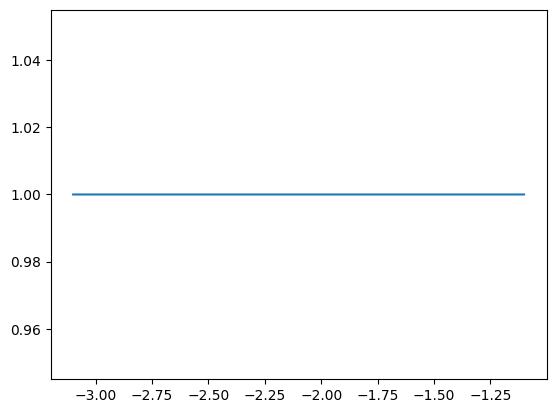

In [34]:
with open('data_ferro_xxz.pkl', 'rb') as f:
    data = pickle.load(f)

N = 10

m = []
for item in data:
    m.append(cal_m(item['v'][1], N))

delta_list = [item['delta'] for item in data]
plt.plot(delta_list, m)

In [ ]:
## phase study of the XXZ model

N = 8

delta = np.arange(-1.5, 1.5, 0.1)

m_list = []

for d in delta:
    H = H_xxz(10, d)
    e, v = np.linalg.eigh(H)

    m_list.append(cal_m(v[:,0], 10))

plt.plot(delta, m_list, 'o')

KeyboardInterrupt: 

(1024,)
(1,)
[-13.5        -13.5        -11.85521847 ...  18.28947463  18.9499485
  20.02981565]


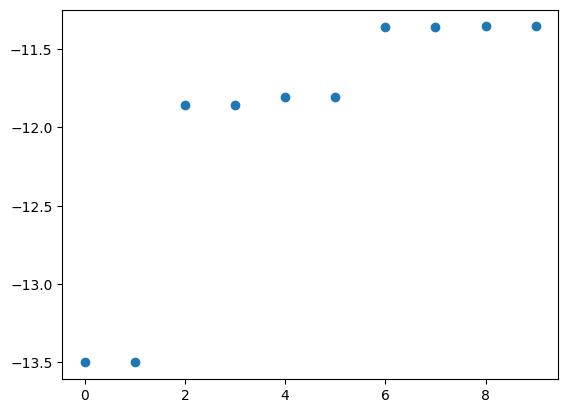

In [27]:
N = 10
H = H_xxz(N, -1.5)
print(H.shape[-1:])
sigma = 1e-8
eps = sigma * np.random.normal(H.shape[-1:])
print(eps.shape)
e, v = np.linalg.eigh(H)
plt.plot(e[:10], 'o')
print(e)

In [2]:
import pickle
with open('data_ferro_xxz_debiased_observables.pkl', 'rb') as f:
    data = pickle.load(f)

print(data[0])

{'delta': -3.1, 'obs_value': array([ 0.        ,  0.        , -0.57511681,  0.        ,  0.        ,
       -0.57511681,  0.        ,  0.        , -0.57511681,  0.        ,
        0.        , -0.57511681,  0.        ,  0.        , -0.57511681,
        0.        ,  0.        , -0.57511681,  0.        ,  0.        ,
       -0.57511681,  0.        ,  0.        , -0.57511681,  0.        ,
        0.        , -0.57511681,  0.        ,  0.        , -0.57511681])}


In [6]:
import numpy as np           # swap to jax.numpy as needed

arr = np.arange(1,10)        # your array
mean_third_excluding_0 = arr[2::3]
print(arr)
print(mean_third_excluding_0)



[1 2 3 4 5 6 7 8 9]
[3 6 9]


In [28]:
with open('data_gapless_xxz_observables.pkl', 'rb') as f:
    data = pickle.load(f)
print(data[0])

{'delta': -0.9, 'obs_value': array([ 2.64548393e-15,  0.00000000e+00,  1.31145095e-15, -2.56728822e-15,
        0.00000000e+00,  1.13797860e-15,  2.41097067e-15,  0.00000000e+00,
        6.48786580e-16, -2.30447052e-15,  0.00000000e+00,  7.97972799e-17,
        2.24085908e-15,  0.00000000e+00, -3.74700271e-16, -2.20461562e-15,
        0.00000000e+00, -5.06539255e-16,  2.20866865e-15,  0.00000000e+00,
       -5.96744876e-16, -2.05044896e-15,  0.00000000e+00, -4.30211422e-16,
        1.98620102e-15,  0.00000000e+00, -5.82867088e-16, -1.99079899e-15,
        0.00000000e+00, -4.44089210e-16])}


In [9]:
N = 10

obs_list = []

for i in range(10):
    obs_list.append(prod(N, [i], [Sx]))
    obs_list.append(prod(N, [i], [Sy]))
    obs_list.append(prod(N, [i], [Sz]))


In [11]:
with open('data_gapless_xxz.pkl', 'rb') as f:
    data = pickle.load(f)
print(data[0])

{'delta': -0.9, 'v': array([ 0.00000000e+00+0.j, -1.71905351e-34+0.j,  2.11756386e-34+0.j, ...,
        0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j])}


In [13]:
obs_values_list = []

for item in data:
    obs_values = np.zeros(len(obs_list), dtype=np.float64)
    for i in range(len(obs_list)):
        obs = obs_list[i]
        obs_values[i] = ((np.vdot(item['v'], obs @ item['v'])).real)
    obs_values_list.append({'delta': item['delta'], 'obs_value': obs_values})

In [14]:
with open('data_gapless_xxz_observables.pkl', 'wb') as f:
    pickle.dump(obs_values_list, f)

In [16]:
print(len(obs_values_list[0]['obs_value']))

30


### XXZ+h model

In [9]:
def H_xxzh(delta, h, J=1):
    ham_xx = prod(N,[0,1],[Sx,Sx])
    ham_yy = prod(N,[0,1],[Sy,Sy])
    ham_zz = prod(N,[0,1],[Sz,Sz])

    ham_x = prod(N, [0], [Sx]) 

    for i in range(1,N-1):
        ham_xx += prod(N, [i,i+1], [Sx, Sx])
        ham_yy += prod(N, [i,i+1], [Sy, Sy])
        ham_zz += prod(N, [i,i+1], [Sz, Sz])

        ham_x += prod(N, [i], [Sx]) 

    ham_x += prod(N, [N-1], [Sx])  

    H_mat = (ham_xx + ham_yy + ham_zz * delta) * J + h * ham_x
    return H_mat

First, let's look at the spectrum of this Hamiltonian.

In [10]:
def find_non_zeors(wf):
    count = 0
    for i in range(len(wf)):
        if wf[i] > 1e-3:
            print(i, wf[i])
            count += 1
    print('count:', count)
    return 

Delta: -2, Eigenvalues: [-18.01061063 -18.01061063 -15.01223546 -15.01223545 -15.00353038
 -15.00353037 -14.64881686 -14.64874184 -14.63613146 -14.63597539]
Delta: -1.5, Eigenvalues: [-13.51323468 -13.51323468 -11.86470554 -11.86470554 -11.81534182
 -11.81534182 -11.39092491 -11.39055526 -11.39045603 -11.39007491]
Delta: -1.1, Eigenvalues: [-9.91831161 -9.91831161 -9.56042213 -9.56042211 -9.40051336 -9.40051335
 -9.30702456 -9.30701648 -9.21575214 -9.21574894]


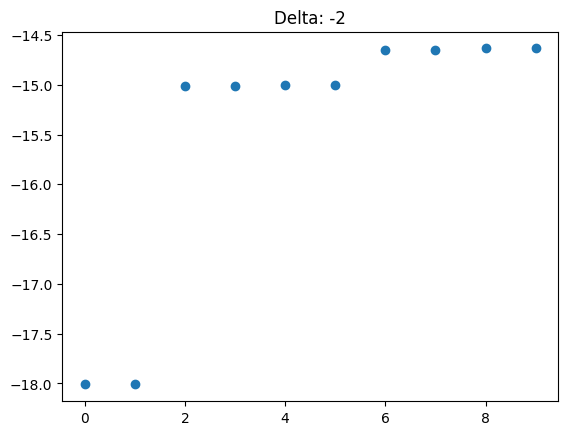

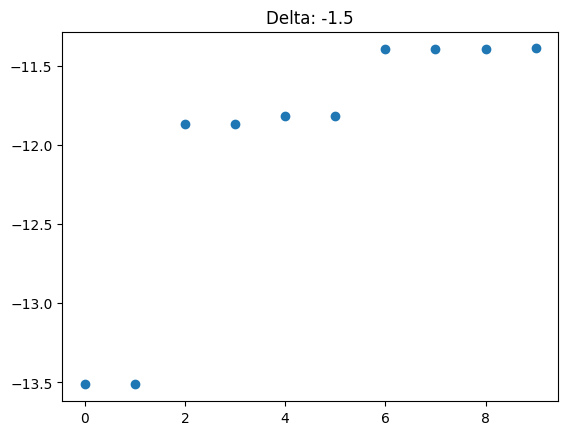

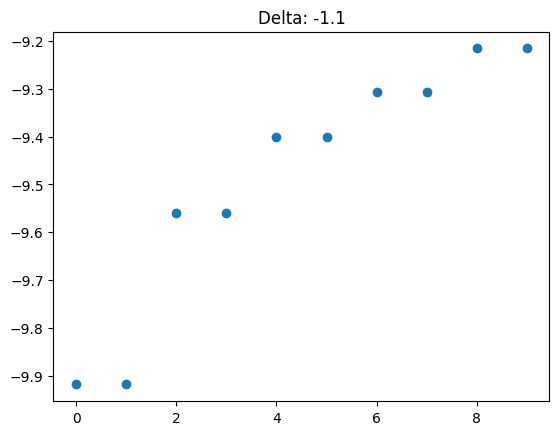

In [26]:
h = 0.1

for delta in [-2, -1.5, -1.1]:
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    print(f"Delta: {delta}, Eigenvalues: {e[:10]}")
    # find_non_zeors(v[:, 0])
    # find_non_zeors(v[:, 1])
    # print()
    # print('\t', v[:, 0])
    # print('\t', v[:, 1])

    plt.figure()
    plt.plot(e[:10], 'o')
    plt.title(f"Delta: {delta}")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Magnetization')

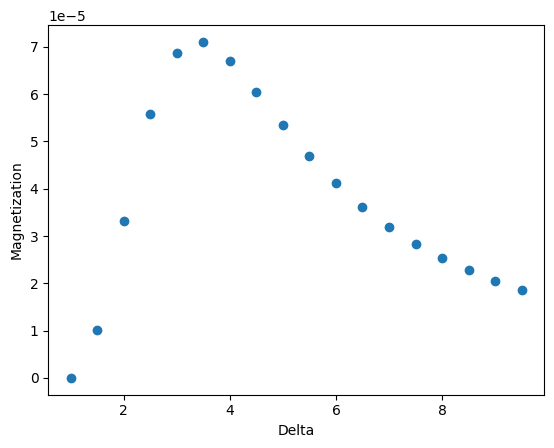

In [71]:
h = 0.1
N = 10

delta_list = np.arange(1, 10, 0.5)

m_list = []
for delta in delta_list:
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    m_list.append(cal_m(v[:,0], N))

plt.figure()
plt.plot(delta_list, m_list, 'o')
plt.xlabel('Delta')
plt.ylabel('Magnetization')


In [51]:
len(np.arange(-0.9, 0.9, 0.005))

360

In [ ]:
N = 10
h = 0.1

delta_list = np.arange(-0.9, 0.9, 0.005)

data_ferro = []
for delta in delta_list:
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    data_ferro.append({'delta': delta,
                    'v': v[:,0]
                    })
    
with open('data_gapless_xxzh.pkl', 'wb') as f:
    pickle.dump(data_ferro, f)
    

Text(0, 0.5, 'Magnetization')

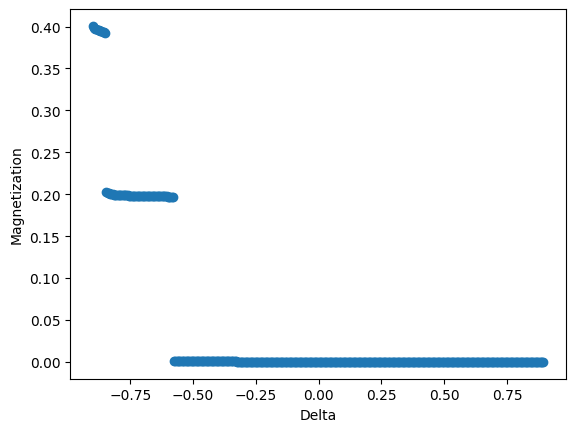

In [59]:
m_list = []
for item in data_ferro:
    m_list.append(cal_m(item['v'], N))

plt.figure()
plt.plot(delta_list, m_list, 'o')
plt.xlabel('Delta')
plt.ylabel('Magnetization')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Magnetization')

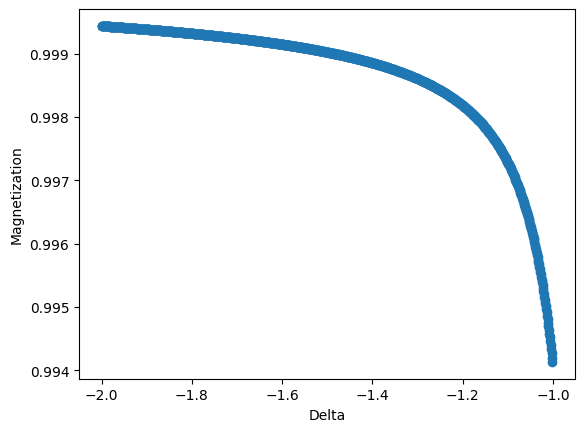

In [ ]:
with open('data_ferro_xxzh.pkl', 'rb') as f:
    data_ferro = pickle.load(f)

d_list = []
m_list = []
for item in data_ferro:
    d_list.append(item['delta'])
    m_list.append(cal_m(item['v'], N))

plt.figure()
plt.plot(d_list, m_list, 'o')
plt.xlabel('Delta')
plt.ylabel('Magnetization')

In [7]:
## randomly draw 1000 samples from the two-dimensional parameter space defined by delta and h

num = 1000                       
delta_min, delta_max = -2.5, -1.5
h_min, h_max =  0.0,  0.5

# uniform samples
deltas = np.random.uniform(delta_min, delta_max, size=num)
hs = np.random.uniform(h_min, h_max, size=num)

param_pair = np.column_stack((deltas, hs))  
print(len(param_pair))


1000


In [11]:
N = 10

data = []
for pair in param_pair:
    delta, h = pair
    print(f"Delta: {delta}, h: {h}")
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    data.append({'param': [delta, h], 'v': v[:,0]})

with open('data_ferro_xxzh.pkl', 'wb') as f:
    pickle.dump(data, f)

Delta: -2.0487685015375465, h: 0.038438132239505984
Delta: -2.308247551831405, h: 0.48471268917092325
Delta: -2.0259979115864706, h: 0.19651591850972883
Delta: -1.7662375117838733, h: 0.3363498703010626
Delta: -1.7097018988760342, h: 0.12281139874947744
Delta: -2.1644274709078033, h: 0.2767764371793766
Delta: -1.5426261990607193, h: 0.348434919362165
Delta: -1.8703562367826514, h: 0.49631065910728606
Delta: -1.9661460230324188, h: 0.32803814674686704
Delta: -1.7557719787899382, h: 0.4026219668810381
Delta: -1.9035312198116099, h: 0.18496160876074713
Delta: -1.568514833731304, h: 0.15155989287108385
Delta: -1.520753762075223, h: 0.29859481347337263
Delta: -1.5949947999803111, h: 0.36400749246457165
Delta: -2.041717014860167, h: 0.4487466574242208
Delta: -2.453955263702643, h: 0.043424482504847484
Delta: -1.5266695160595285, h: 0.3446055839140676
Delta: -2.3350681376469886, h: 0.11463938168263083
Delta: -1.5665199883588057, h: 0.4346152879321987
Delta: -1.6822579383874032, h: 0.181044547

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/axes/_axes.py:4458: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


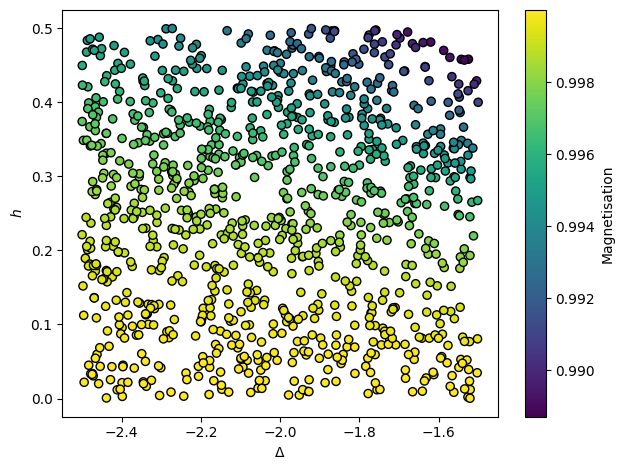

In [19]:
with open('data_ferro_xxzh.pkl', 'rb') as f:
    data_ferro = pickle.load(f)

d_list = []
h_list = []
m_list = []
for item in data_ferro:
    d_list.append(item['param'][0])
    h_list.append(item['param'][1])
    m_list.append(cal_m(item['v'], N))

d = np.asarray(d_list)
h = np.asarray(h_list)
m = np.asarray(m_list)

fig, ax = plt.subplots()
sc = ax.scatter(d, h, c=m, cmap='viridis', s=35, edgecolor='k')
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$h$')
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Magnetisation')
plt.tight_layout()
plt.show()

In [ ]:
## randomly draw 1000 samples from the two-dimensional parameter space defined by delta and h from a different phase

num = 1000                       
delta_min, delta_max = -0.5, 0.5
h_min, h_max =  0.0,  0.5

# uniform samples
deltas = np.random.uniform(delta_min, delta_max, size=num)
hs = np.random.uniform(h_min, h_max, size=num)

param_pair = np.column_stack((deltas, hs))  
print(len(param_pair))

N = 10

data = []
for pair in param_pair:
    delta, h = pair
    # print(f"Delta: {delta}, h: {h}")
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    data.append({'param': [delta, h], 'v': v[:,0]})

# with open('data_neelY_xxzh.pkl', 'wb') as f:
#     pickle.dump(data, f)


1000


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/axes/_axes.py:4458: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


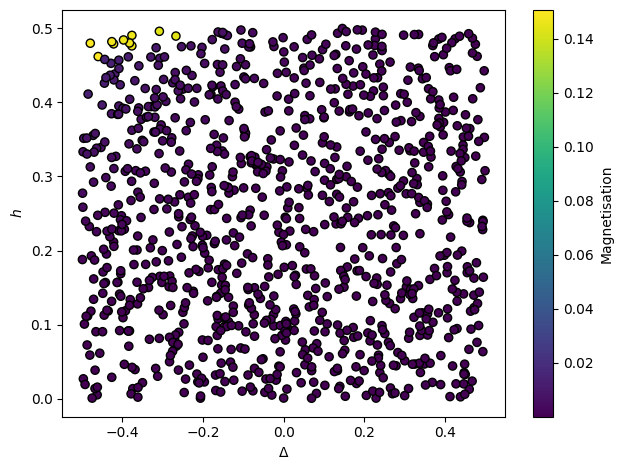

In [23]:
with open('data_neelY_xxzh.pkl', 'rb') as f:
    data_ferro = pickle.load(f)

d_list = []
h_list = []
m_list = []
for item in data_ferro:
    d_list.append(item['param'][0])
    h_list.append(item['param'][1])
    m_list.append(cal_m(item['v'], N))

d = np.asarray(d_list)
h = np.asarray(h_list)
m = np.asarray(m_list)

fig, ax = plt.subplots()
sc = ax.scatter(d, h, c=m, cmap='viridis', s=35, edgecolor='k')
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$h$')
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Magnetisation')
plt.tight_layout()
plt.show()

In [24]:
## randomly draw 1000 samples from the two-dimensional parameter space defined by delta and h from a different phase

num = 500                       
delta_min, delta_max = -2, -1
h_min, h_max =  2.0,  3.0

# uniform samples
deltas = np.random.uniform(delta_min, delta_max, size=num)
hs = np.random.uniform(h_min, h_max, size=num)

param_pair = np.column_stack((deltas, hs))  
print(len(param_pair))

N = 10

data = []
for pair in param_pair:
    delta, h = pair
    # print(f"Delta: {delta}, h: {h}")
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    data.append({'param': [delta, h], 'v': v[:,0]})

with open('data_nlroX4_xxzh.pkl', 'wb') as f:
    pickle.dump(data, f)


500


In [ ]:
## get the debiased data for the ferro phase

N = 10

num = 1000                       
delta_min, delta_max = -2.0, -1.1
h_min, h_max =  0.0,  0.5

# uniform samples
deltas = np.random.uniform(delta_min, delta_max, size=num)
hs = np.random.uniform(h_min, h_max, size=num)

param_pair = np.column_stack((deltas, hs))  

data_db = []
for pair in param_pair:
    delta, h = pair
    H = H_xxzh(delta, h)
    e, v = np.linalg.eigh(H)
    # data.append({'param': [delta, h], 'v': v[:,0]})

    ## debiasing data
    gd1, gd2 = v[:,0], v[:,1]
    c1, c2 = np.random.normal(size=2)
    norm = np.sqrt(c1**2+c2**2)
    wf = (c1*gd1 + c2*gd2) / norm
    data_db.append({'param': [delta, h], 'v': wf})

# with open('data_ferro_xxzh_debiased.pkl', 'wb') as f:
#     pickle.dump(data_db, f)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/matplotlib/axes/_axes.py:4458: ComplexWarning: Casting complex values to real discards the imaginary part
  c = np.asanyarray(c, dtype=float)


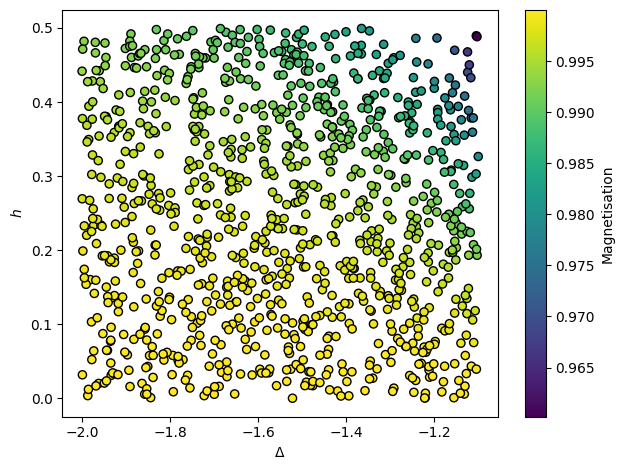

In [29]:
d_list = []
h_list = []
m_list = []
for item in data_db:
    d_list.append(item['param'][0])
    h_list.append(item['param'][1])
    m_list.append(cal_m(item['v'], N))

d = np.asarray(d_list)
h = np.asarray(h_list)
m = np.asarray(m_list)

fig, ax = plt.subplots()
sc = ax.scatter(d, h, c=m, cmap='viridis', s=35, edgecolor='k')
ax.set_xlabel(r'$\Delta$')
ax.set_ylabel(r'$h$')
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Magnetisation')
plt.tight_layout()
plt.show()